# Perceptron


In [194]:
#importando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt



In [195]:
#função de treinamento do Perceptron
def perceptron_treinamento(dados, pesos):

    #taxa de aprendizado
    n = 0.001

    #controle
    erro = 1
    epocas = 0

    while( erro == 1):
        erro = 0
        epocas += 1
        erro_medio = 0

        for i in range(len(dados)):
            v = 0

            for j in range(len(pesos)):
                v += dados[i][j] * pesos[j] #funçaõ Sum{i_>M)(W*X)
            
            #função sinal
            y = np.sign(v) #vai retorna +1 se c1 e -1 se c2
            erro_medio += (dados[i][3] -y) * (dados[i][3] - y)

            #atualizacao dos pesos
            if(dados[i,3] != y):
                erro = 1
                for j in range(len(pesos)):
                    pesos[j] += n*(dados[i][3] - y) * dados[i][j]
        #calcula a media do erro sobre todos os exemplos
        erro_medio = erro_medio / len(dados)
        print("\nÉpoca", epocas, "| Erro médio = ", erro_medio)

    print("\nFinalizado com ", epocas,"epocas\n")

    return pesos

In [196]:
#funcao de aplicacao do perceptron treinado
def perceptron(exemplo, pesos):
    v = 0

    for i in range(len(exemplo)):
        #potencial de ativação
        v = v + exemplo[i] * pesos[i]

    #funcao sinal
    y = np.sign(v)

    return y

In [197]:
# Vamos criar um conjunto de dados artificial
x1 = [4, 2, 5, 3, 1.5, 2.5, 4, 5, 1.5, 3, 5, 4]
x2 = [5, 4.5, 4.5, 4, 3, 3, 3, 3, 1.5, 2, 1.5, 1]
bias = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
classe = np.array([1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, -1])

# Concatena as colunas para criar o conjunto de dados
dados = np.c_[x1,x2,bias,classe]
print(dados)

[[ 4.   5.   1.   1. ]
 [ 2.   4.5  1.  -1. ]
 [ 5.   4.5  1.   1. ]
 [ 3.   4.   1.   1. ]
 [ 1.5  3.   1.  -1. ]
 [ 2.5  3.   1.  -1. ]
 [ 4.   3.   1.   1. ]
 [ 5.   3.   1.   1. ]
 [ 1.5  1.5  1.  -1. ]
 [ 3.   2.   1.  -1. ]
 [ 5.   1.5  1.   1. ]
 [ 4.   1.   1.  -1. ]]


In [198]:
#gerando os pesos randomicamente
pesos = np.random.uniform(-1,1, 3)
print(pesos)

[0.69436111 0.28708794 0.38543013]


In [199]:
#aplicando o perceptron
novos_pesos = perceptron_treinamento(dados, pesos.copy())
print(novos_pesos)
print(pesos)



Época 1 | Erro médio =  2.0

Época 2 | Erro médio =  2.0

Época 3 | Erro médio =  2.0

Época 4 | Erro médio =  2.0

Época 5 | Erro médio =  2.0

Época 6 | Erro médio =  2.0

Época 7 | Erro médio =  2.0

Época 8 | Erro médio =  2.0

Época 9 | Erro médio =  2.0

Época 10 | Erro médio =  2.0

Época 11 | Erro médio =  2.0

Época 12 | Erro médio =  2.0

Época 13 | Erro médio =  2.0

Época 14 | Erro médio =  2.0

Época 15 | Erro médio =  2.0

Época 16 | Erro médio =  1.6666666666666667

Época 17 | Erro médio =  1.3333333333333333

Época 18 | Erro médio =  1.3333333333333333

Época 19 | Erro médio =  2.0

Época 20 | Erro médio =  2.0

Época 21 | Erro médio =  2.0

Época 22 | Erro médio =  2.0

Época 23 | Erro médio =  2.0

Época 24 | Erro médio =  2.0

Época 25 | Erro médio =  2.0

Época 26 | Erro médio =  2.0

Época 27 | Erro médio =  1.6666666666666667

Época 28 | Erro médio =  2.0

Época 29 | Erro médio =  1.6666666666666667

Época 30 | Erro médio =  2.0

Época 31 | Erro médio =  2.333333

In [200]:
# Vamos traçar o hiperplano gerado pelo nosso Perceptron

# Traçando o hiperplano
# Toda equação na forma y = mx + q é chamada equação reduzida da reta,
# em que m é o coeficiente angular, e q é a ordenada do ponto no qual a reta cruza o eixo y.
# A equação reduzida pode ser obtida diretamente da equação geral ax + by + c = 0. Assim:

# ax + by + c = 0 -> by = -ax –c

# y = -a/b x  - c/b

# m = -a/b
# q = -c/b

intercept = - novos_pesos[2] / novos_pesos[1]
slope = - novos_pesos[0] / novos_pesos[1]

print(intercept)
print(slope)

9.109819501315751
-1.8850483497878043


In [201]:
# Função para plotar uma reta dado um slope e um intercept
def abline(slope, intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

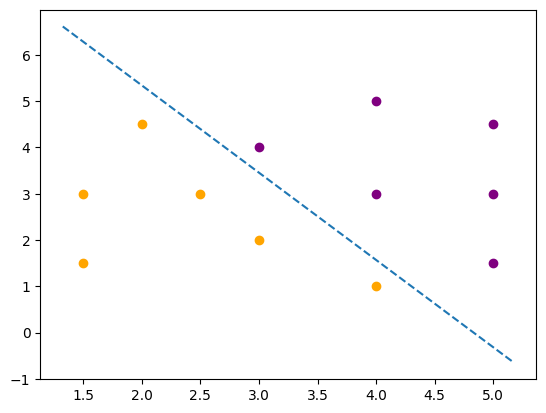

In [202]:
# Vamos plotar os nossos dados e o hiperplano
cores = ("orange", "purple")
fig, ax = plt.subplots()

j = 0
for rotulo in (-1,1):
    ax.scatter(dados[classe==rotulo][:, 0],
               dados[classe==rotulo][:, 1],
               c=cores[j],
               label=str(j))
    j = j+1

# Hiperplano
abline(slope,intercept)

In [203]:
# Classifica novos dados
print(perceptron((1,1,1),novos_pesos))
print(perceptron((4,4,1),novos_pesos))

-1.0
1.0


In [204]:
# Importando o conjunto de dados
from sklearn.datasets import load_iris

iris = load_iris()

In [205]:
#nome das features
print(iris.target_names)

#dividindo entre entrada e saida (2 atributos)
X_iris = iris.data[:, :2]
y_iris =  iris.target


print(X_iris[0:10])

print(y_iris)

['setosa' 'versicolor' 'virginica']
[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]
 [5.4 3.9]
 [4.6 3.4]
 [5.  3.4]
 [4.4 2.9]
 [4.9 3.1]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


/tmp/ipykernel_10405/2587547432.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_iris[:, 0], X_iris[:, 1], c=color[y_iris], cmap=plt.cm.Set1, edgecolor="k")


([], [])

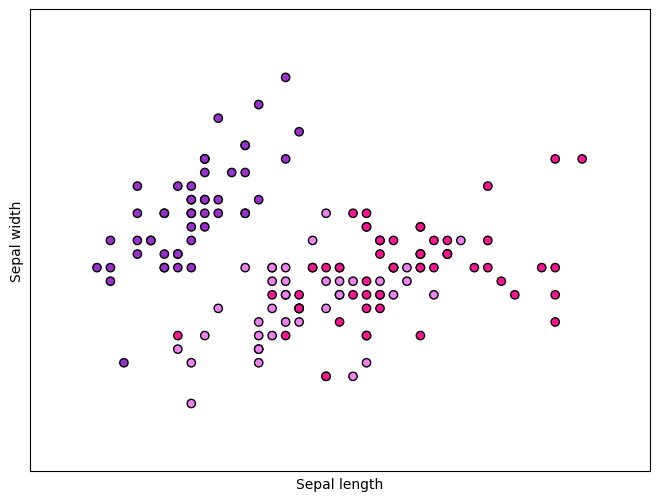

In [206]:
# Vamos plotar os dados
x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5

plt.figure(2, figsize=(8, 6))
plt.clf()
color = np.array(["darkorchid", "violet","deeppink"])
# Plot the training points
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=color[y_iris], cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())

In [207]:
# Vamos rotular a classe setosa como positiva e o resto como negativa
print(y_iris)
y_iris[y_iris > 0] = -1
y_iris[y_iris == 0] = 1
print("Novos estados de classes: ",y_iris)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Novos estados de classes:  [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1]


In [208]:
bias_iris =  np.ones(len(X_iris))
dados_iris = np.c_[X_iris, bias_iris, y_iris]
print("Os dados finais")
print("  X1  | X2 | Bias | Y")
print(dados_iris)

Os dados finais
  X1  | X2 | Bias | Y
[[ 5.1  3.5  1.   1. ]
 [ 4.9  3.   1.   1. ]
 [ 4.7  3.2  1.   1. ]
 [ 4.6  3.1  1.   1. ]
 [ 5.   3.6  1.   1. ]
 [ 5.4  3.9  1.   1. ]
 [ 4.6  3.4  1.   1. ]
 [ 5.   3.4  1.   1. ]
 [ 4.4  2.9  1.   1. ]
 [ 4.9  3.1  1.   1. ]
 [ 5.4  3.7  1.   1. ]
 [ 4.8  3.4  1.   1. ]
 [ 4.8  3.   1.   1. ]
 [ 4.3  3.   1.   1. ]
 [ 5.8  4.   1.   1. ]
 [ 5.7  4.4  1.   1. ]
 [ 5.4  3.9  1.   1. ]
 [ 5.1  3.5  1.   1. ]
 [ 5.7  3.8  1.   1. ]
 [ 5.1  3.8  1.   1. ]
 [ 5.4  3.4  1.   1. ]
 [ 5.1  3.7  1.   1. ]
 [ 4.6  3.6  1.   1. ]
 [ 5.1  3.3  1.   1. ]
 [ 4.8  3.4  1.   1. ]
 [ 5.   3.   1.   1. ]
 [ 5.   3.4  1.   1. ]
 [ 5.2  3.5  1.   1. ]
 [ 5.2  3.4  1.   1. ]
 [ 4.7  3.2  1.   1. ]
 [ 4.8  3.1  1.   1. ]
 [ 5.4  3.4  1.   1. ]
 [ 5.2  4.1  1.   1. ]
 [ 5.5  4.2  1.   1. ]
 [ 4.9  3.1  1.   1. ]
 [ 5.   3.2  1.   1. ]
 [ 5.5  3.5  1.   1. ]
 [ 4.9  3.6  1.   1. ]
 [ 4.4  3.   1.   1. ]
 [ 5.1  3.4  1.   1. ]
 [ 5.   3.5  1.   1. ]
 [ 4.5  2.3  1.   1

In [209]:
#gerando os pesos aleatoriamente entre ]-1, -1[
pesos_iris = np.random.uniform(-1,1, 3)
print(pesos_iris)

[-0.14101717 -0.29770502  0.48498674]


In [210]:
#Treinando o modelos = atualizando os pesos
novos_pesos_iris = perceptron_treinamento(dados_iris,pesos_iris.copy()) 
print("Pesos iniciais: ", pesos_iris)
print("Pesos após o treinamento: ", novos_pesos_iris)


Época 1 | Erro médio =  0.6133333333333333

Época 2 | Erro médio =  0.32

Época 3 | Erro médio =  0.29333333333333333

Época 4 | Erro médio =  0.32

Época 5 | Erro médio =  0.29333333333333333

Época 6 | Erro médio =  0.26666666666666666

Época 7 | Erro médio =  0.26666666666666666

Época 8 | Erro médio =  0.24

Época 9 | Erro médio =  0.26666666666666666

Época 10 | Erro médio =  0.21333333333333335

Época 11 | Erro médio =  0.21333333333333335

Época 12 | Erro médio =  0.21333333333333335

Época 13 | Erro médio =  0.21333333333333335

Época 14 | Erro médio =  0.18666666666666668

Época 15 | Erro médio =  0.16

Época 16 | Erro médio =  0.16

Época 17 | Erro médio =  0.16

Época 18 | Erro médio =  0.16

Época 19 | Erro médio =  0.16

Época 20 | Erro médio =  0.16

Época 21 | Erro médio =  0.10666666666666667

Época 22 | Erro médio =  0.10666666666666667

Época 23 | Erro médio =  0.10666666666666667

Época 24 | Erro médio =  0.10666666666666667

Época 25 | Erro médio =  0.1066666666666

In [211]:
#traçando o hiperplano gerado pelo perceptron quando a função y = 0
# w1X+ w2Y + bias = 0
intercept = - novos_pesos_iris[2] / novos_pesos_iris[1]
coef_angular = - novos_pesos_iris[0] / novos_pesos_iris[1]

print(intercept)
print(coef_angular)

-5.366776741322327
1.6070694692253007


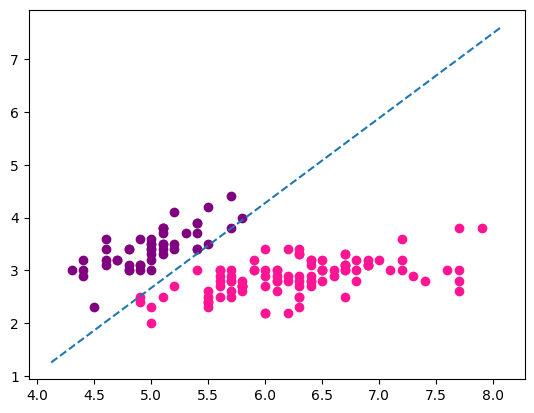

In [212]:
#plotando os nossos dados
cores = ("deeppink", "purple")
fig, ax = plt.subplots()

j = 0
for rotulo in (-1,1):
    ax.scatter(dados_iris[y_iris==rotulo][:, 0],
               dados_iris[y_iris==rotulo][:, 1],
               c=cores[j],
               label=str(j))
    j = j+1

abline(coef_angular,intercept)

In [213]:
# Classifica novos dados
print(perceptron((7,2.5,1),novos_pesos_iris))
print(perceptron((4.5,4,1),novos_pesos_iris))

-1.0
1.0
